# Eigenvector preparation

**Goal:** Given an n-qubit diagonal unitary U with distinct eigenvalues in computational basis,
a promised integer d such that $2^d * θ(x) \in\mathbb{Z}$ for all $x$, and a promised target $t \in [0,1)$
such that there is a unique $x^*$ with

   $$ U |x^*\rangle = e^{2π i t} |x^*\rangle,$$

we build a **fully coherent** Qiskit circuit that prepares $|x^*\rangle$.

This construction uses only 1-qubit gates and multi-control phase (MCP) and X (MCX) gates, **and does not need measurements**.


## Inputs

- `eigs`: length-2^n list/array of eigenvalues of U in computational-basis order.
          i.e. eigs[x] = exp(2π i θ(x)) for x as an integer 0..2^n-1.
- `n`: number of search qubits
- `d`: promised number of phase bits (we use m=d phase qubits)
- `t`: target phase in [0,1). Under promise, t is a dyadic fraction with denominator $2^d$ (mod 1).

## Constraints respected

- No measurements
- No classical bits
- Allowed: 1-qubit gates, multi-controlled X/phase, QFT
- Classical preprocessing on U: computing powers of diagonal eigenvalues is used

---

## High-level circuit structure

The circuit consists of 
- *d phase registers* and 
- *n search registers*

We build a Grover iterate on the search register S:

$$G = U_t \cdot D$$

where:
- $U_t$ is a phase oracle that multiplies |x*> by -1 and leaves all other |x> unchanged.
- $D$ is the standard Grover diffuser on S.

### Oracle $U_t$

The oracle $U(t)$ is built as: 

1. QPE(U) on (phase register P, search register S). 
2. Compare phase bits in P to the d-bit binary representation of t
3. If equal, kick back a -1 phase using a flag ancilla
4. Uncompute (inverse QPE) so P returns to $|0…0\rangle$

This implements:

$$U_t |x\rangle = -|x\rangle \quad \text{if}\,\, θ(x)=t (\text{mod}\,\, 1)$$
$$|x\rangle \quad \text{otherwise}$$





In [ ]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFTGate, UnitaryGate, Diagonal

from typing import List, Sequence, Optional

from scipy.stats import unitary_group

import pylatexenc

import matplotlib.pyplot as plt

import numpy as np

#-----------------------
# Classical preprocessing
#-----------------------

def quantize_t_to_int(t: float, d: int) -> int:
    # Convert target phase t to integer T = (2^d * t) mod 2^d.
    M = 1 << d
    return int(round((t % 1.0) * M)) % M

def int_to_bits_le(x: int, m: int) -> List[int]:
    # Convert integer x to a list of m bits in little-endian order, i.e., most significant bit last.
    list_of_bits = [(x >> k) & 1 for k in range(m)]
    return list_of_bits

def power_eigs(eigs: Sequence[complex], power: int) -> List[complex]:
    # Compute U^power eigenvalues from U eigenvalues.
    return [v ** power for v in eigs] 

def inv_eigs(eigs: Sequence[complex]) -> List[complex]:
    # Compute U^\dagger eigenvalues
    return [np.conjugate(v) for v in eigs]

def as_complex_list(vals: Sequence[complex]) -> List[complex]:
    # Important: covert to complex type to avoid issues with qiskit diagonal gates.
    return [complex(v) for v in vals]


# -------------------------
# QPE builder for diagonal U
# -------------------------

def build_qpe_gate(eigs: Sequence[complex], n: int, m: int, name: str = "QPE", inverse: bool = False):
    # Build a coherent QPE gate for a diagonal U specified by eigenvalues.
    # Use m qubits for phase register and n qubits for search register. 

    # Forward QPE pattern:
    #  - Hadamard on all P
    #  - controlled-U^{2^k} from P[k] to S
    #  - inverse-QFT on P

    # If inverse=True, equivalent to uncompute QPE

    # Note: The QPE is set up in a way that phase is encoded in the phase register in little-endian order, 
    # i.e., the least significant bit of the phase is stored in P[0].

    eigs = as_complex_list(eigs)
    if len(eigs) != (1 << n):
        raise ValueError(f"Expected {1<<n} eigenvalues for n={n}, got {len(eigs)}")

    Phase_register = QuantumRegister(m, "P")
    Search_register = QuantumRegister(n, "S")
    qc = QuantumCircuit(Phase_register, Search_register, name=(name + ("†" if inverse else "")))

    if not inverse:
        qc.h(Phase_register)
        for k in range(m):
            power = 1 << k
            pow_eigs = power_eigs(eigs, power)
            U_pow = Diagonal(pow_eigs).to_gate(label=f"U^{power}")
            qc.append(U_pow.control(1), [Phase_register[k], *Search_register])

        qc.append(QFTGate(num_qubits=m).inverse(), Phase_register)

    else:
        qc.append(QFTGate(num_qubits=m), Phase_register)
        for k in range(m):
            power = 1 << k
            pow_eigs = power_eigs(eigs, power)
            pow_eigs = inv_eigs(pow_eigs)
            U_pow_dag = Diagonal(pow_eigs).to_gate(label=f"U^{power}†")
            qc.append(U_pow_dag.control(1), [Phase_register[k], *Search_register])

        qc.h(Phase_register)

    return qc


# -------------------------
# Grover diffuser on phase register
# -------------------------

def build_diffuser(n: int, name: str = "D"):
    # Standard n-qubit Grover diffuser on search register: H^n · (2|0><0| - I) · H^n
    #  - H, X on all qubits
    #  - multi-controlled Z (via H on last + MCX + H on last)
    #  - X, H on all qubits

    Search_register = QuantumRegister(n, "S")
    diffuser = QuantumCircuit(Search_register, name=name)

    diffuser.h(Search_register)
    diffuser.x(Search_register)
    if n == 1:
        diffuser.z(Search_register[0])
    else:
        diffuser.mcp(np.pi,list(Search_register[:-1]), Search_register[n - 1])
    diffuser.x(Search_register)
    diffuser.h(Search_register)
    return diffuser

# -------------------------
# Grover marker on search register
# -------------------------

def build_phase_oracle(eigs: Sequence[complex], n: int, d: int, t: float, name: str = "U_t",):
    # Build oracle U_t as a Gate acting on (P, S):
    #  - QPE(U) on (P,S)
    #  - X gates to test P == T (T = 2^d t mod 2^d)
    #  - conditional -1 phase via MCX into |-> flag
    #  - undo X gates
    #  - inverse QPE(U) on (P,S)

    eigs = as_complex_list(eigs)

    m = d
    T_int = quantize_t_to_int(t, d)
    T_bits = int_to_bits_le(T_int, m) # Now T = 2^d t mod 2^d is represented as a list of bits (in big-endian order).

    Phase_register = QuantumRegister(m, "phase")
    Search_register = QuantumRegister(n, "search")

    Phase_oracle = QuantumCircuit(Phase_register, Search_register, name=name)

    # QPE forward
    Phase_oracle.append(build_qpe_gate(eigs, n=n, m=m, inverse=False).to_gate(), [*Phase_register, *Search_register])

    # Map equality to all-ones by X on bits where T has 0
    for k, bit in enumerate(T_bits):
        if bit == 0:
            Phase_oracle.x(Phase_register[k])

    # Multi-controlled Z on phase register
    Phase_oracle.mcp(np.pi,list(Phase_register[:-1]), Phase_register[m - 1])

    # Undo the masking X gates
    for k, bit in enumerate(T_bits):
        if bit == 0:
            Phase_oracle.x(Phase_register[k])

    # Uncompute QPE
    Phase_oracle.append(build_qpe_gate(eigs, n=n, m=m, inverse=True).to_gate(), [*Phase_register, *Search_register])

    return Phase_oracle


# -------------------------
# Full circuit builder
# -------------------------

def build_grover_qpe_circuit(eigs: Sequence[complex], n: int, d: int, t: float, grover_iters: Optional[int] = None,):
    # Full circuit consists:
    #  - state preparation of |+>^n on search register
    #  - K iterations of Grover. (K = [pi / (4 * arcsin(1 / sqrt(2^n)) - 1/2)])
    
    if grover_iters is None:
        grover_iters = int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(1 << n))) - 1/2))

    Phase_register = QuantumRegister(d, "phase")
    Search_register = QuantumRegister(n, "search")
    qc = QuantumCircuit(Phase_register, Search_register, name="Grover_QPE")

    U_t = build_phase_oracle(eigs=eigs, n=n, d=d, t=t)
    diffuser = build_diffuser(n)

    # State preparation:
    qc.h(Search_register)

    for _ in range(grover_iters):
        qc.append(U_t, [*Phase_register, *Search_register])
        qc.append(diffuser, [*Search_register])

    return qc

## Example: n=3, d=3

In this case, K=2. Therefore, the circuit runs 2 iterations of the Grover oracle.

/var/folders/nr/9bj2cy4x5j515g9vw4_m4_940000gn/T/ipykernel_96646/542358634.py:59: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.diagonal.Diagonal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use DiagonalGate instead.
  U_pow = Diagonal(pow_eigs).to_gate(label=f"U^{power}")
/var/folders/nr/9bj2cy4x5j515g9vw4_m4_940000gn/T/ipykernel_96646/542358634.py:70: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.diagonal.Diagonal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use DiagonalGate instead.
  U_pow_dag = Diagonal(pow_eigs).to_gate(label=f"U^{power}†")


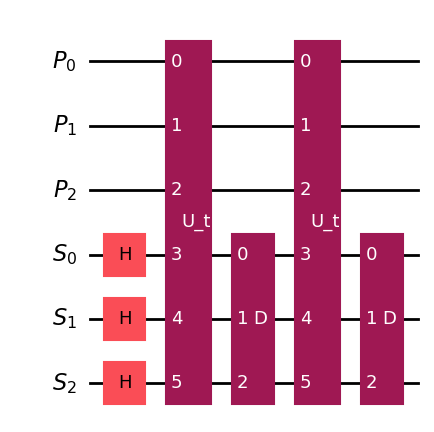

In [37]:
n = 3
d = 3
t = 0.125
eigs = [1,np.exp(1j*np.pi/4),np.exp(1j*np.pi/2),np.exp(3*1j*np.pi/4),-1,np.exp(5*1j*np.pi/4),np.exp(3*1j*np.pi/2),np.exp(7*1j*np.pi/4)]

qpe=build_qpe_gate(eigs,n,d)
qpe_inv=build_qpe_gate(eigs,n,d,inverse=True)
U_t=build_phase_oracle(eigs,n,d,t)
grover_qpe = build_grover_qpe_circuit(eigs,n,d,t)

Phase_register = AncillaRegister(d, "P")
Search_register = QuantumRegister(n, "S")
Grover_qpe_circuit = QuantumCircuit(Phase_register, Search_register, name="QPE with diffuser")

#Grover_qpe_circuit.h(Search_register)
#Grover_qpe_circuit.compose(qpe, inplace=True)
#Grover_qpe_circuit.compose(qpe_inv, inplace=True)
#Grover_qpe_circuit.compose(U_t, inplace=True)
#Grover_qpe_circuit.compose(build_diffuser(3), qubits=Search_register[:], inplace=True)
Grover_qpe_circuit.compose(grover_qpe, inplace=True)
Grover_qpe_circuit.draw("mpl")

In [38]:
psi = Statevector(Grover_qpe_circuit)
output_distribution = np.round(psi.probabilities(),4)
output_distribution

array([0.0078, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.9453, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.0078, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.0078, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.0078, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.0078, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.0078, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.0078, 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ])

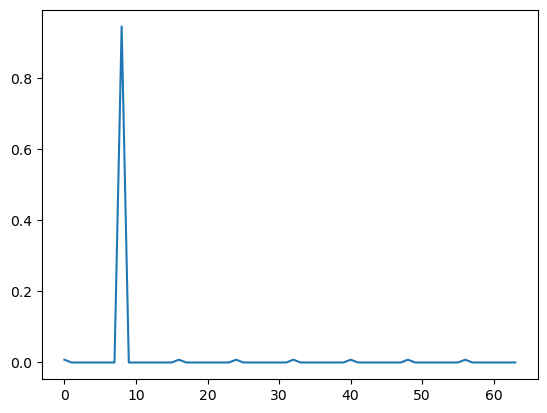

In [39]:
plt.plot(np.arange(2**(n+d)), output_distribution)

In [40]:
x_star = np.where(output_distribution >= 1/2)[0]
print(int_to_bits_le(quantize_t_to_int(t,d), d))
print(int_to_bits_le(int(x_star[0]), n+d))

[1, 0, 0]
[0, 0, 0, 1, 0, 0]


In [41]:
psi.draw("latex")

<IPython.core.display.Latex object>

### Error

In [46]:
error = 1- max(output_distribution)/1
print(f"Error =  {error:.4f}", f"which is less than 2^-3 = {1/(2**3):.4f}")

Error =  0.0547 which is less than 2^-3 = 0.1250


## Example: n=6, d=6

In this case, K=6. Therefore, the circuit runs 6 iterations of the Grover oracle.

/var/folders/nr/9bj2cy4x5j515g9vw4_m4_940000gn/T/ipykernel_96646/542358634.py:59: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.diagonal.Diagonal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use DiagonalGate instead.
  U_pow = Diagonal(pow_eigs).to_gate(label=f"U^{power}")
/var/folders/nr/9bj2cy4x5j515g9vw4_m4_940000gn/T/ipykernel_96646/542358634.py:70: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.diagonal.Diagonal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use DiagonalGate instead.
  U_pow_dag = Diagonal(pow_eigs).to_gate(label=f"U^{power}†")


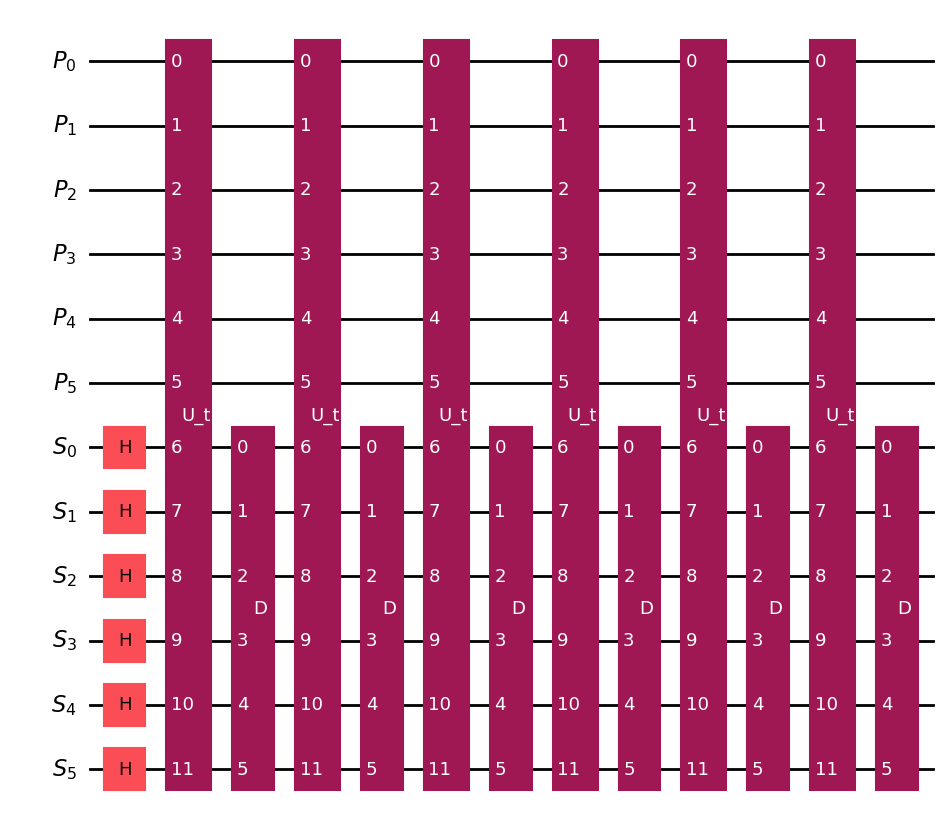

In [48]:
n = 6
d = 6
N = 1 << n
t = 1/N
eigs = [np.exp(i*1j*2*np.pi/N) for i in range(N)]

qpe=build_qpe_gate(eigs,n,d)
qpe_inv=build_qpe_gate(eigs,n,d,inverse=True)
U_t=build_phase_oracle(eigs,n,d,t)
grover_qpe = build_grover_qpe_circuit(eigs,n,d,t)

Phase_register = AncillaRegister(d, "P")
Search_register = QuantumRegister(n, "S")
Grover_qpe_circuit = QuantumCircuit(Phase_register, Search_register, name="QPE with diffuser")

#Grover_qpe_circuit.h(Search_register)
#Grover_qpe_circuit.compose(qpe, inplace=True)
#Grover_qpe_circuit.compose(qpe_inv, inplace=True)
#Grover_qpe_circuit.compose(U_t, inplace=True)
#Grover_qpe_circuit.compose(build_diffuser(3), qubits=Search_register[:], inplace=True)
Grover_qpe_circuit.compose(grover_qpe, inplace=True)
Grover_qpe_circuit.draw("mpl")

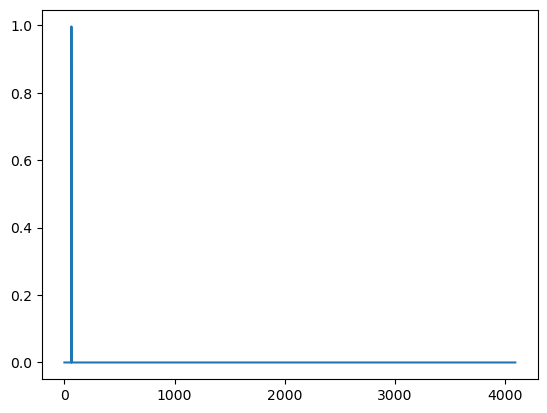

In [49]:
psi = Statevector(Grover_qpe_circuit)
output_distribution = np.round(psi.probabilities(),4)
plt.plot(np.arange(2**(n+d)), output_distribution)

In [50]:
x_star = np.where(output_distribution >= 1/2)[0]
print(int_to_bits_le(quantize_t_to_int(t,d), d))
print(int_to_bits_le(int(x_star[0]), n+d))
psi.draw("latex")

[1, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]


<IPython.core.display.Latex object>

### Error

In [51]:
error = 1- max(output_distribution)/1
print(f"Error =  {error:.4f}", f"which is less than 1/2^{n:.0f} = {1/N:.4f}")

Error =  0.0034 which is less than 1/2^6 = 0.0156


# K calculator

In [26]:
n=6
K = int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(1 << n))) - 1/2))
print(K)

6
